# 9.0 Network Analysis of Coalitions

While our machine learning models successfully isolated the feature importance of coalition strength on individual electoral outcomes, they treated parties as independent entities. In reality, the Indian party system is a highly interdependent ecosystem. In this chapter, we apply Network Analysis (Graph Theory) to mathematically map the architecture of pre-poll alliances, quantifying how power and influence flow through regional and national party linkages.

**Reference files used:**
- `ReferenceData/state_crosswalk.csv` — canonical state codes, valid-from/to years, bifurcation history  
- `ReferenceData/state_name_audit.csv` — raw state names identified during the audit pass  
- `ReferenceData/state_name_variants.csv` — variant → canonical name lookup (also used in cleanup notebook)

**Filtered inputs expected:**
```
FilteredData/clean_election_results_1951_2019.csv
FilteredData/clean_loksabha_1962_2019.csv
FilteredData/clean_election_results_2024.csv
FilteredData/clean_ref_party_master.csv
FilteredData/features_dataset.csv
```

---
## Imports & Data Loading

In [3]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.tsa.arima.model import ARIMA
import ruptures as rpt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.metrics import accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [4]:
# ─── Reference files ────────────────────────────────────────────────────────
state_crosswalk     = pd.read_csv('ReferenceData/state_crosswalk.csv')
state_name_audit    = pd.read_csv('ReferenceData/state_name_audit.csv')
state_name_variants = pd.read_csv('ReferenceData/state_name_variants.csv')

# ─── Cleaned election datasets (output of cleanup notebook) ─────────────────
df_1951_2019 = pd.read_csv('FilteredData/clean_election_results_1951_2019.csv')
df_loksabha  = pd.read_csv('FilteredData/clean_loksabha_1962_2019.csv')
df_2024      = pd.read_csv('FilteredData/clean_election_results_2024.csv')
df_party     = pd.read_csv('FilteredData/clean_ref_party_master.csv')
df_features  = pd.read_csv('FilteredData/features_dataset.csv')
# ________________ Additional Datasets_________________________
df_state_gdp  = pd.read_csv('FilteredData/clean_state_gdp_share.csv')
df_literacy_51_11  = pd.read_csv('FilteredData/clean_literacy_1951_2011.csv')

print('Loaded datasets:')
print(f'  clean_election_results_1951_2019 : {df_1951_2019.shape}')
print(f'  clean_loksabha_1962_2019         : {df_loksabha.shape}')
print(f'  clean_election_results_2024      : {df_2024.shape}')
print(f'  clean_ref_party_master           : {df_party.shape}')
print(f'  df_features                      : {df_features.shape}')
print(f'  df_state_gdp                     : {df_state_gdp.shape}')
print(f'  df_literacy_51_11                : {df_literacy_51_11.shape}')

Loaded datasets:
  clean_election_results_1951_2019 : (89840, 19)
  clean_loksabha_1962_2019         : (8047, 15)
  clean_election_results_2024      : (8902, 16)
  clean_ref_party_master           : (10153, 27)
  df_features                      : (89840, 30)
  df_state_gdp                     : (291, 10)
  df_literacy_51_11                : (7, 5)


In [5]:
df_model = pd.read_csv("Sub Datasets/df_model.csv")
df_model_clean = pd.read_csv("Sub Datasets/df_model_clean.csv")
df_mixed_clean = pd.read_csv("Sub Datasets/df_mixed_clean.csv")
df_logit = pd.read_csv("Sub Datasets/df_logit.csv")
ts_data = pd.read_csv("Sub Datasets/ts_data.csv")
predicted_classes = pd.read_csv("Sub Datasets/predicted_classes.csv")
predicted_probs = pd.read_csv("Sub Datasets/predicted_probes.csv")
predictions_mixed = pd.read_csv("Sub Datasets/predictions_mix.csv")
predictions = pd.read_csv("Sub Datasets/predictions.csv")
df_cv = pd.read_csv("Sub Datasets/df_cv.csv")

# Print shape of each DataFrame
print("df_model:", df_model.shape)
print("df_model_clean:", df_model_clean.shape)
print("df_mixed_clean:", df_mixed_clean.shape)
print("df_logit:", df_logit.shape)
print("ts_data:", ts_data.shape)
print("predicted_classes:", predicted_classes.shape)
print("predicted_probs:", predicted_probs.shape)
print("predictions_mixed:", predictions_mixed.shape)
print("predictions:", predictions.shape)
print("df_cv:", df_cv.shape)

df_model: (90747, 34)
df_model_clean: (4773, 34)
df_mixed_clean: (4773, 34)
df_logit: (63993, 30)
ts_data: (18, 1)
predicted_classes: (63993, 1)
predicted_probs: (63993, 1)
predictions_mixed: (4773, 1)
predictions: (90747, 1)
df_cv: (63993, 30)


## 9.1 Data Preparation & Graph Construction

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# 1. Extract national party weights (average vote share per party per year)
# Assuming your columns are named 'party' and 'alliance' (adjust if capitalized)
party_weights = df_features.groupby(['election_year_clean', 'alliance', 'party'])['vote_share_pct'].mean().reset_index()

def build_historical_network(df, target_year):
    """Builds a weighted undirected graph for a specific election year."""
    # Filter for the target year and drop independent/unallied parties
    df_year = df[(df['election_year_clean'] == target_year) & (df['alliance'].notna())]
    
    G = nx.Graph()
    
    # Group by alliance to find all parties in the same coalition
    for alliance_name, group in df_year.groupby('alliance'):
        parties = group['party'].tolist()
        shares = group.set_index('party')['vote_share_pct'].to_dict()
        
        # Add nodes with their individual vote share as a node attribute
        for p in parties:
            G.add_node(p, weight=shares[p], alliance=alliance_name)
            
        # Create edges between every pair of parties in the same alliance
        for party_A, party_B in combinations(parties, 2):
            # The edge weight is the combined strength of the two parties
            combined_strength = shares[party_A] + shares[party_B]
            G.add_edge(party_A, party_B, weight=combined_strength)
            
    return G

# Let's build the graphs for a highly fragmented year (e.g., 1996) and a hegemonic year (e.g., 2019)
# Replace these years with the exact integers present in your 'election_year_clean' column
G_1996 = build_historical_network(party_weights, 1996)
G_2019 = build_historical_network(party_weights, 2019)

print(f"1996 Network: {G_1996.number_of_nodes()} parties, {G_1996.number_of_edges()} alliance links")
print(f"2019 Network: {G_2019.number_of_nodes()} parties, {G_2019.number_of_edges()} alliance links")

1996 Network: 206 parties, 20303 alliance links
2019 Network: 674 parties, 224117 alliance links


## 9.2 Calculating Network Metrics

In [7]:
def calculate_network_metrics(G):
    """Calculates Degree, Betweenness, and Clustering for the network."""
    # If graph is empty, return empty dataframe
    if G.number_of_nodes() == 0:
        return pd.DataFrame()
        
    degree_centrality = nx.degree_centrality(G)
    # Weight is inverted for betweenness because NetworkX treats weights as 'distance'
    # High vote share = closer relationship = shorter distance
    distance_dict = {(u, v): 1 / d['weight'] for u, v, d in G.edges(data=True)}
    nx.set_edge_attributes(G, distance_dict, 'distance')
    
    betweenness_centrality = nx.betweenness_centrality(G, weight='distance')
    clustering_coeff = nx.clustering(G)
    
    metrics_df = pd.DataFrame({
        'Party': list(G.nodes()),
        'Degree': list(degree_centrality.values()),
        'Betweenness': list(betweenness_centrality.values()),
        'Clustering': list(clustering_coeff.values())
    }).set_index('Party').sort_values(by='Betweenness', ascending=False)
    
    return metrics_df

# Calculate and display the metrics for the coalition era
metrics_1996 = calculate_network_metrics(G_1996)
print("\nTop Coalition Brokers in 1996 (Highest Betweenness):")
print(metrics_1996.head())


Top Coalition Brokers in 1996 (Highest Betweenness):
         Degree  Betweenness  Clustering
Party                                   
SDF    0.980488     0.897561         1.0
BJP    0.004878     0.000000         0.0
DMK    0.004878     0.000000         0.0
INC    0.004878     0.000000         0.0
ABBNS  0.980488     0.000000         1.0


## 9.3 Network Visualization (Core-Periphery Structure)

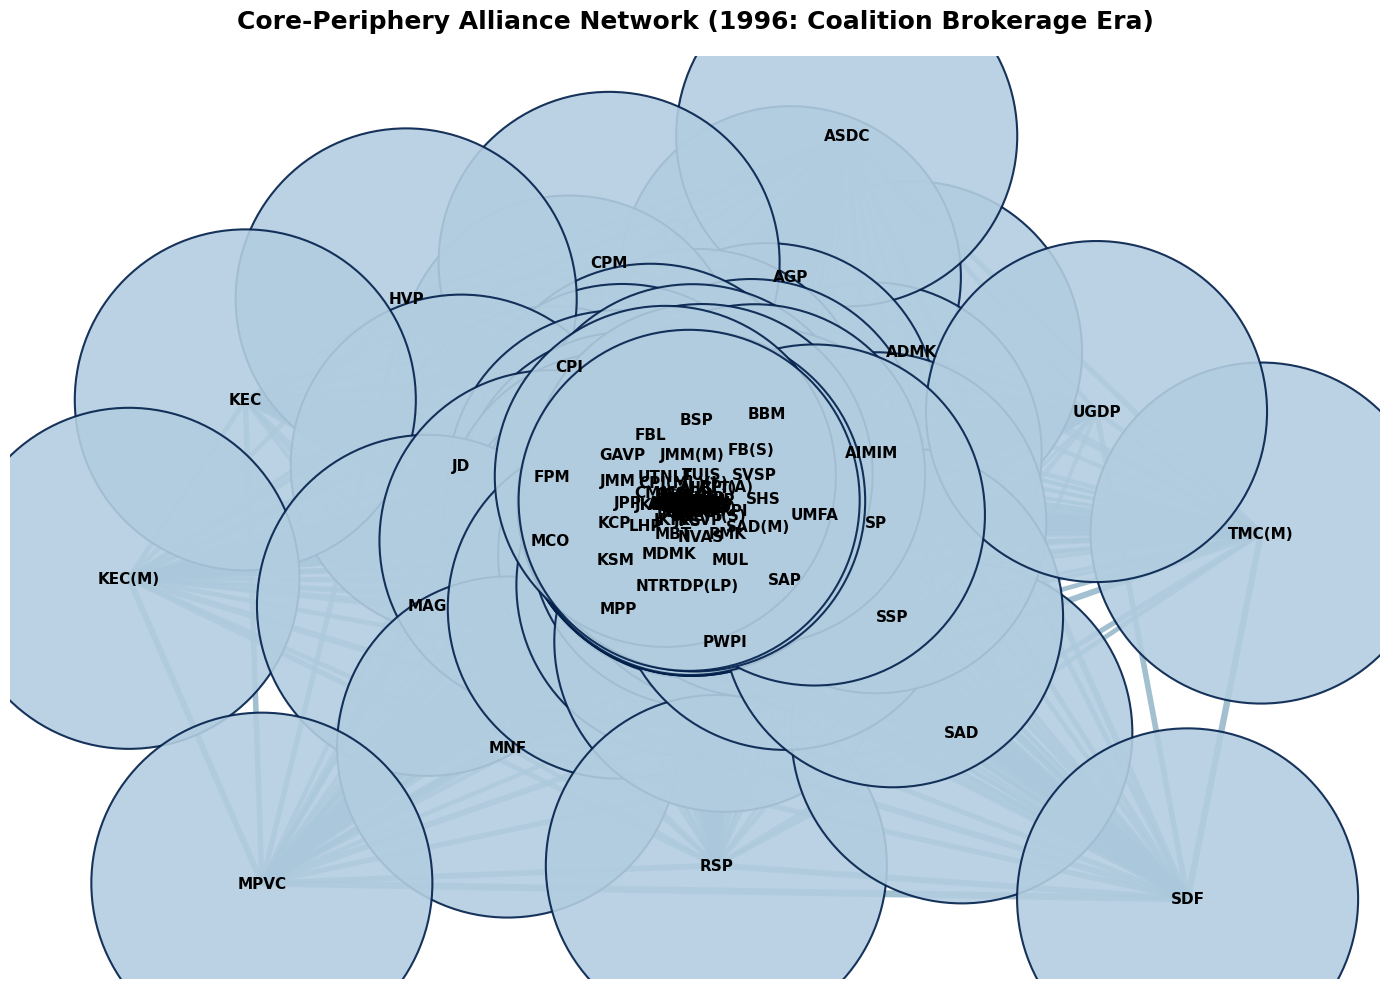

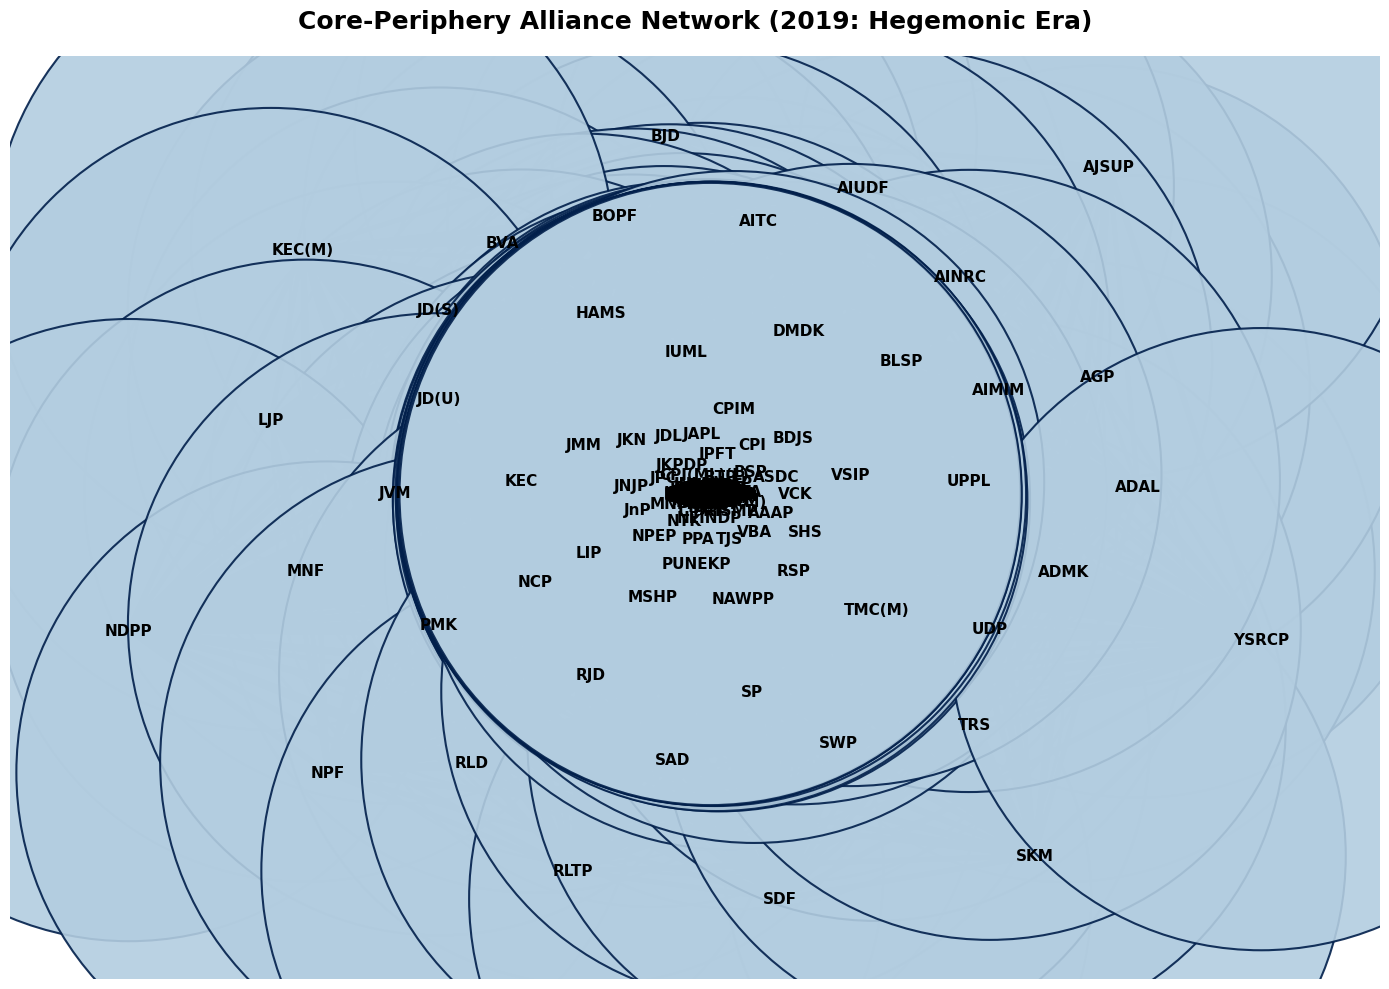

In [8]:
def plot_alliance_network(G, title):
    """Visualizes the core-periphery architecture of the electoral alliances."""
    if G.number_of_nodes() == 0:
        print(f"No alliance data available to plot for {title}")
        return
        
    plt.figure(figsize=(14, 10))
    
    # Use Kamada-Kawai layout for optimal clustering visibility
    pos = nx.kamada_kawai_layout(G, weight='weight')
    
    # Node sizing: scale by degree centrality so hegemonic parties are massive
    degrees = dict(G.degree())
    node_sizes = [v * 300 for v in degrees.values()]
    
    # Edge coloring and thickness based on combined vote share weight
    edges = G.edges()
    weights = [G[u][v]['weight'] for u, v in edges]
    
    # Normalize weights for visualization
    max_weight = max(weights) if weights else 1
    edge_widths = [(w / max_weight) * 5 for w in weights]
    
    # Draw the network
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='#b3cde0', 
                           edgecolors='#011f4b', linewidths=1.5, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color='#6497b1', alpha=0.6)
    
    # Add labels only for the most central parties to avoid text clutter
    labels = {node: node for node, deg in degrees.items() if deg > (max(degrees.values()) * 0.2)}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=11, font_weight='bold', font_family='sans-serif')
    
    plt.title(title, fontsize=18, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# Visualize the historical shift
plot_alliance_network(G_1996, "Core-Periphery Alliance Network (1996: Coalition Brokerage Era)")
plot_alliance_network(G_2019, "Core-Periphery Alliance Network (2019: Hegemonic Era)")